# Final Project

**Course:** AI For HR Management


**Student name:** Tokanaeva Aisana , Zharova Malika

**Student ID:** 242676 , 241767

IMPORT LIBRARIES

In [8]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

# Handling imbalance
from imblearn.over_sampling import SMOTE

# For statistical tests (used in fairness audit)
from scipy.stats import chi2_contingency

# For model explainability (SHAP)
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    print("SHAP not installed. Model explainability will be skipped.")
    SHAP_AVAILABLE = False

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

Data Preparation

In [4]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("HRDataset_v14.csv")

print("=" * 60)
print("INITIAL DATASET OVERVIEW")
print("=" * 60)

print(f"\nDataset Shape: {df.shape}")

print("\nDataset Preview:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

# ============================================================
# CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

# ============================================================
# CLEAN TEXT COLUMNS
# ============================================================

print("\nCleaning text columns...")

text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
    )

# ============================================================
# HANDLE MISSING VALUES
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing_before = df.isnull().sum()

print("\nMissing Values Before Cleaning:")
print(missing_before[missing_before > 0])

# ---------------------------
# NUMERIC COLUMNS
# ---------------------------

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    missing_count = df[col].isnull().sum()

    if missing_count > 0:
        median_value = df[col].median()

        df[col] = df[col].fillna(median_value)

        print(
            f"[Numeric] {col}: "
            f"{missing_count} missing values filled "
            f"with median ({median_value:.2f})"
        )

# ---------------------------
# CATEGORICAL COLUMNS
# ---------------------------

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:

    missing_count = df[col].isnull().sum()

    if missing_count > 0:

        mode_value = df[col].mode()[0]

        df[col] = df[col].fillna(mode_value)

        print(
            f"[Categorical] {col}: "
            f"{missing_count} missing values filled "
            f"with mode ({mode_value})"
        )

print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())

# ============================================================
# REMOVE DUPLICATES
# ============================================================

print("\n" + "=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

duplicates = df.duplicated().sum()

print(f"\nDuplicate Rows Found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()

    print(f"Duplicate rows removed successfully.")

print(f"\nDataset Shape After Cleaning: {df.shape}")

# ============================================================
# CONVERT DATA TYPES
# ============================================================

print("\n" + "=" * 60)
print("DATA TYPE CONVERSION")
print("=" * 60)

# ---------------------------
# CONVERT SALARY TO NUMERIC
# ---------------------------

if df['Salary'].dtype == 'object':

    df['Salary'] = (
        df['Salary']
        .replace(r'[\$,]', '', regex=True)
    )

    df['Salary'] = pd.to_numeric(
        df['Salary'],
        errors='coerce'
    )

# Fill any conversion errors
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

print("Salary converted to numeric format.")

# ---------------------------
# DATE CONVERSIONS
# ---------------------------

date_cols = [
    'DateofHire',
    'DateofTermination',
    'DOB',
    'LastPerformanceReview_Date'
]

for col in date_cols:

    if col in df.columns:

        df[col] = pd.to_datetime(
            df[col],
            errors='coerce'
        )

        print(f"{col} converted to datetime.")

# ============================================================
# STANDARDIZE CATEGORIES
# ============================================================

print("\n" + "=" * 60)
print("CATEGORY STANDARDIZATION")
print("=" * 60)

# Standardize gender labels
if 'Sex' in df.columns:

    df['Sex'] = df['Sex'].replace({
        'Male': 'M',
        'Female': 'F',
        'male': 'M',
        'female': 'F'
    })

# Standardize department names
if 'Department' in df.columns:

    df['Department'] = (
        df['Department']
        .str.title()
        .str.strip()
    )

# Standardize job titles
if 'Position' in df.columns:

    df['Position'] = (
        df['Position']
        .str.title()
        .str.strip()
    )

print("Categorical values standardized.")

# ============================================================
# MERGE SECONDARY DATASETS
# ============================================================

print("\nNo secondary datasets provided for merging.")

# ============================================================
# CREATE TARGET VARIABLE
# ============================================================

print("\nCreating target variable...")

df['IsTerminated'] = (
    df['DateofTermination']
    .notna()
    .astype(int)
)

# ============================================================
# FEATURE ENGINEERING
# ============================================================

print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

current_date = pd.Timestamp("2026-05-25")

# ------------------------------------------------
# EMPLOYEE END DATE
# ------------------------------------------------

df['End_Date'] = (
    df['DateofTermination']
    .fillna(current_date)
)

# ------------------------------------------------
# YEARS AT COMPANY
# ------------------------------------------------

df['YearsAtCompany'] = (
    df['End_Date'] - df['DateofHire']
).dt.days / 365.25

# ------------------------------------------------
# EMPLOYEE AGE
# ------------------------------------------------

df['Age'] = (
    current_date - df['DOB']
).dt.days / 365.25

# ------------------------------------------------
# DEPARTMENT AVERAGE SALARY
# ------------------------------------------------

dept_avg_salary = (
    df.groupby('Department')['Salary']
    .transform('mean')
)

df['Salary_Vs_Dept_Avg'] = (
    df['Salary'] / dept_avg_salary
)

# ------------------------------------------------
# YEARS SINCE LAST PROMOTION
# ------------------------------------------------

df['YearsSinceLastPromotion'] = (
    df['YearsAtCompany']
    - (df['SpecialProjectsCount'] * 0.3)
)

df['YearsSinceLastPromotion'] = (
    df['YearsSinceLastPromotion']
    .clip(lower=0)
)

# ------------------------------------------------
# PERFORMANCE TREND OVER TIME
# ------------------------------------------------

if 'PerformanceScore' in df.columns:

    performance_map = {
        'PIP': 1,
        'Needs Improvement': 2,
        'Fully Meets': 3,
        'Exceeds': 4,
        'Exceptional': 5
    }

    df['PerformanceScoreNumeric'] = (
        df['PerformanceScore']
        .map(performance_map)
    )

    df['Performance_Trend'] = (
        df['PerformanceScoreNumeric']
        + df['EngagementSurvey']
        + df['EmpSatisfaction']
    ) / 3

else:

    df['Performance_Trend'] = (
        df['EngagementSurvey']
        + df['EmpSatisfaction']
    ) / 2

# ------------------------------------------------
# NORMALIZE VARIABLES
# ------------------------------------------------

def min_max_normalize(series):

    return (
        (series - series.min()) /
        (series.max() - series.min())
    )

df['Absences_Normalized'] = (
    min_max_normalize(df['Absences'])
)

df['Satisfaction_Normalized'] = (
    min_max_normalize(df['EmpSatisfaction'])
)

df['Engagement_Normalized'] = (
    min_max_normalize(df['EngagementSurvey'])
)

# ------------------------------------------------
# EARLY-WARNING ENGAGEMENT RISK SCORE
# ------------------------------------------------

df['Engagement_Risk_Score'] = (
    df['Absences_Normalized'] +
    (1 - df['Satisfaction_Normalized']) +
    (1 - df['Engagement_Normalized'])
) / 3

# ------------------------------------------------
# OVERTIME RISK PROXY
# ------------------------------------------------

df['Overtime_Risk'] = np.where(
    df['Absences'] > df['Absences'].median(),
    1,
    0
)

# ============================================================
# FINAL DATA VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("FINAL DATA VALIDATION")
print("=" * 60)

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Missing Values:")
print(df.isnull().sum().sum())

print("\nDataset Information:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

# ============================================================
# SAVE CLEANED DATASET
# ============================================================

df.to_csv(
    "HR_Cleaned_FeatureEngineered.csv",
    index=False
)

print("\nCleaned dataset saved successfully.")

print("\n" + "=" * 60)
print("TASK 1 COMPLETED SUCCESSFULLY")
print("=" * 60)

from google.colab import files

files.download("HR_Cleaned_FeatureEngineered.csv")

INITIAL DATASET OVERVIEW

Dataset Shape: (311, 36)

Dataset Preview:
              Employee_Name  EmpID  MarriedID  MaritalStatusID  GenderID  \
0       Adinolfi, Wilson  K  10026          0                0         1   
1  Ait Sidi, Karthikeyan     10084          1                1         1   
2         Akinkuolie, Sarah  10196          1                1         0   
3              Alagbe,Trina  10088          1                1         0   
4          Anderson, Carol   10069          0                2         0   

   EmpStatusID  DeptID  PerfScoreID  FromDiversityJobFairID  Salary  ...  \
0            1       5            4                       0   62506  ...   
1            5       3            3                       0  104437  ...   
2            5       5            3                       0   64955  ...   
3            1       5            3                       0   64991  ...   
4            5       5            3                       0   50825  ...   

      ManagerName

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exploratory Analysis

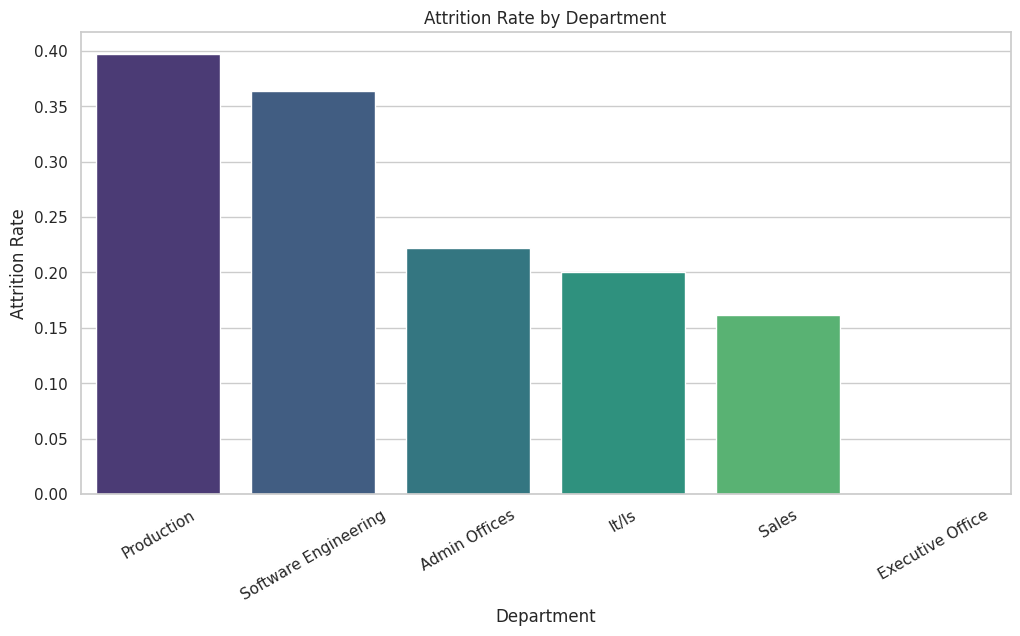


HR Insight:
Departments with high attrition rates may indicate:
- burnout
- leadership problems
- workload imbalance
- weak employee engagement
- compensation dissatisfaction

These departments should be prioritized for HR intervention.



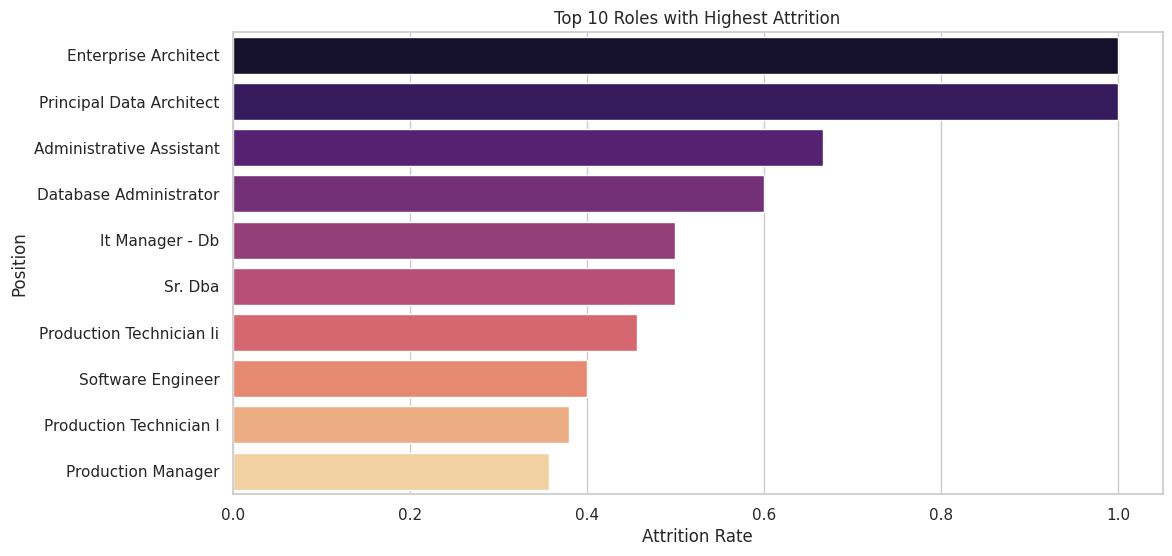


HR Insight:
Operational and sales-oriented roles often experience:
- higher stress
- performance pressure
- customer-facing burnout
- lower long-term retention

These roles may require:
- incentive redesign
- manager coaching
- workload balancing



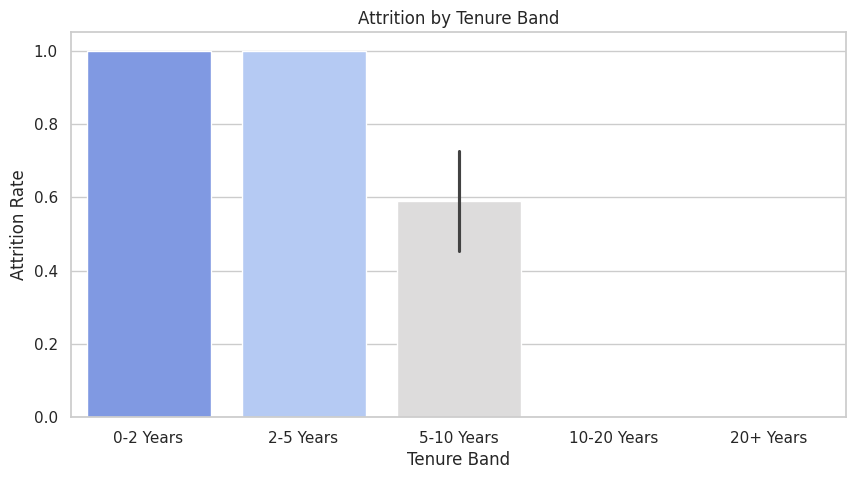


HR Insight:
Employees in their first years are often at the highest
risk of resignation because of:
- onboarding mismatch
- unmet expectations
- limited career clarity
- weak organizational attachment

Early retention programs are critical.



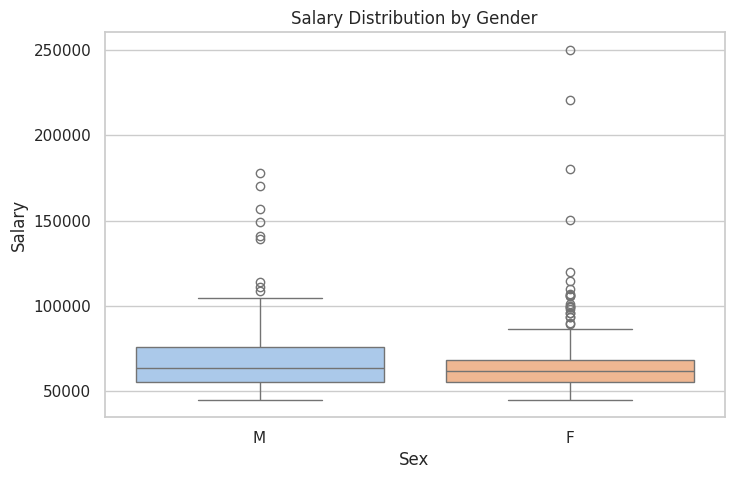


Gender Pay Gap: 4.02%

HR Insight:
Salary inequality damages:
- employee trust
- retention
- morale
- employer reputation

Even moderate pay gaps can increase attrition risk.



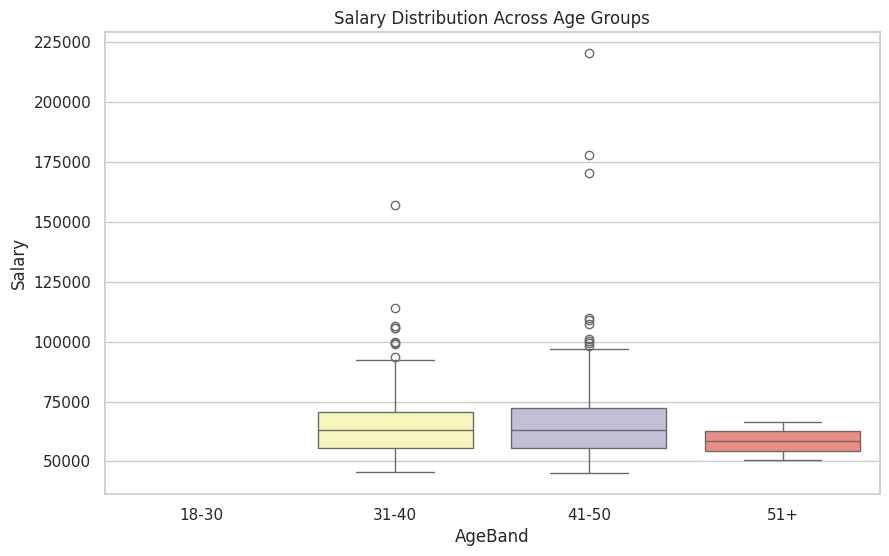


Average Salary by Age Group:
AgeBand
18-30             NaN
31-40    67295.088608
41-50    68667.907692
51+      58511.500000
Name: Salary, dtype: float64

HR Insight:
Large salary differences across age groups may indicate:
- promotion inequality
- experience premiums
- generational imbalance
- possible age bias

HR should ensure compensation remains performance-based.



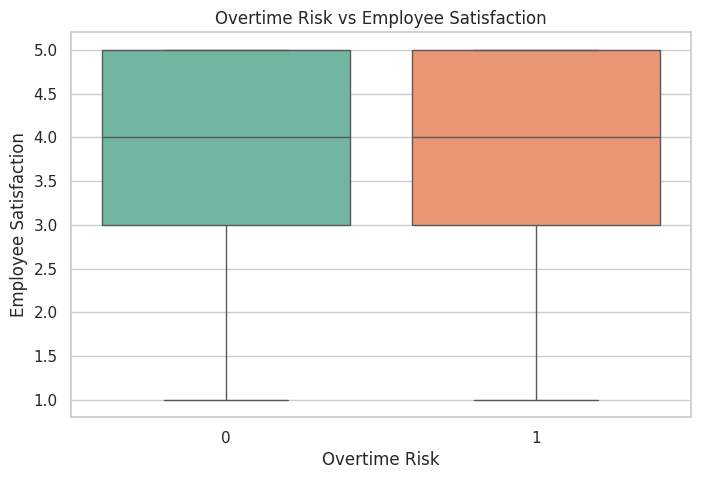


HR Insight:
Employees exposed to excessive workload pressure
typically show:
- lower satisfaction
- reduced engagement
- increased burnout
- higher resignation probability



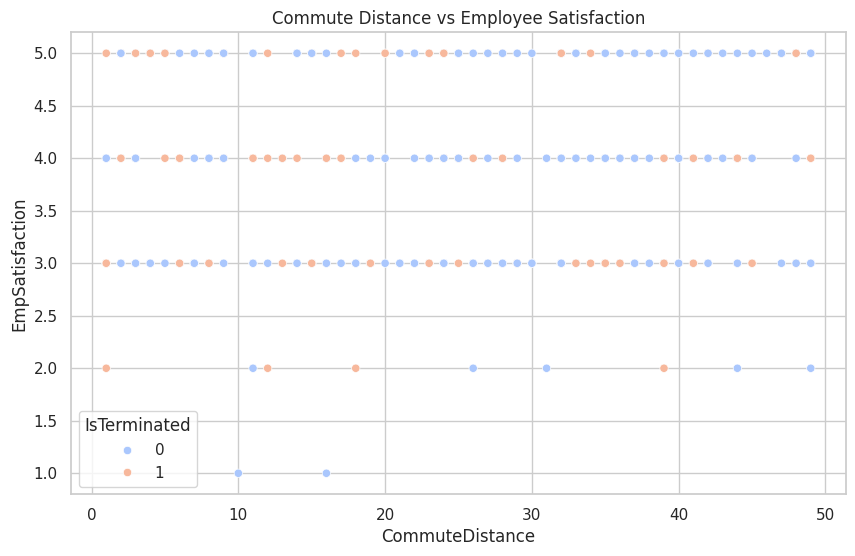


HR Insight:
Long commuting distances are frequently associated with:
- lower morale
- fatigue
- work-life imbalance
- increased attrition risk

Hybrid work policies can help reduce this pressure.



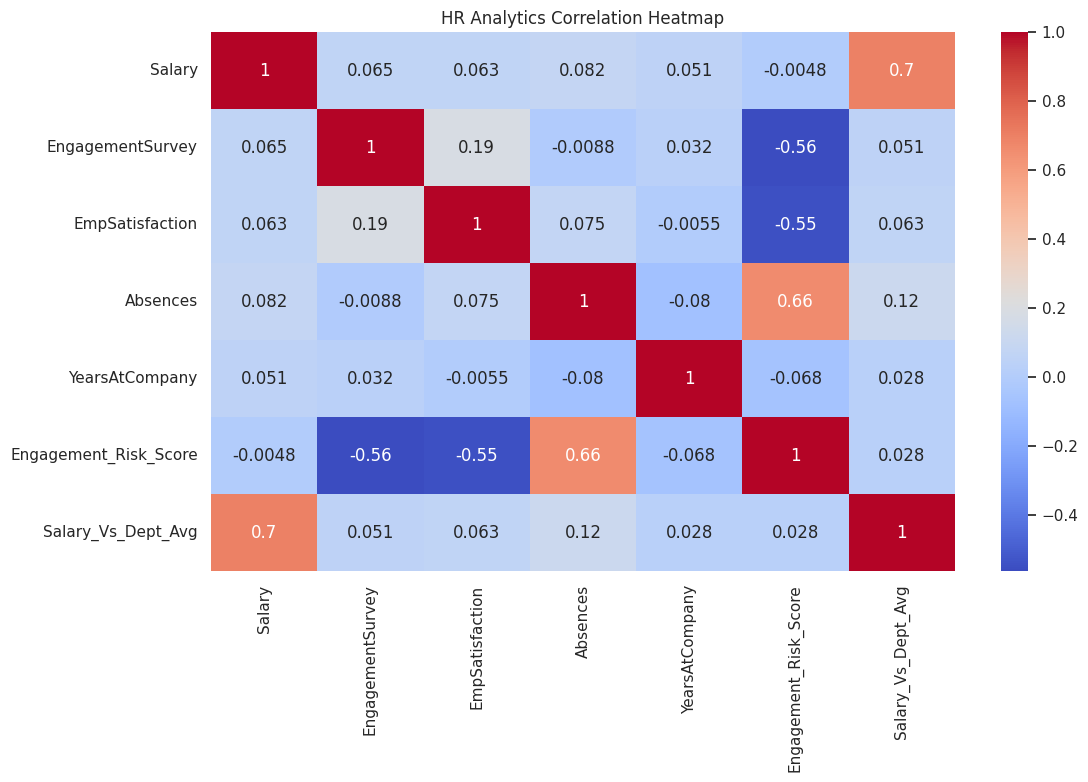


HR Insight:
Strong correlations help HR identify the main drivers of:
- turnover
- dissatisfaction
- absenteeism
- disengagement

These relationships guide strategic HR decision-making.


UNDERPAID HIGH PERFORMERS
         Employee_Name     Department                  Position  Salary  \
9    Bacong, Alejandro          It/Is                It Support   50178   
252     Shepard, Anita          It/Is          Network Engineer   50750   
170   Lindsay, Leonara          It/Is                It Support   51777   
193      Morway, Tanya          It/Is          Network Engineer   52599   
113    Gonzalez, Maria          It/Is                It Support   61242   
99         Galia, Lisa          It/Is                It Support   65707   
261        Soto, Julia          It/Is                It Support   66593   
132    Howard, Estelle  Admin Offices  Administrative Assistant   49920   
48       Clayton, Rick          It/Is                It Support   68678   
255         Singh, Nan  Admin Offic

In [5]:
# ============================================================
# ATTRITION BY DEPARTMENT
# ============================================================

attrition_dept = (
    df.groupby('Department')['IsTerminated']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=attrition_dept.index,
    y=attrition_dept.values,
    palette='viridis'
)

plt.xticks(rotation=30)
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate")
plt.xlabel("Department")

plt.show()

print("""
HR Insight:
Departments with high attrition rates may indicate:
- burnout
- leadership problems
- workload imbalance
- weak employee engagement
- compensation dissatisfaction

These departments should be prioritized for HR intervention.
""")

# ============================================================
# ATTRITION BY ROLE
# ============================================================

role_attrition = (
    df.groupby('Position')['IsTerminated']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=role_attrition.values,
    y=role_attrition.index,
    palette='magma'
)

plt.title("Top 10 Roles with Highest Attrition")
plt.xlabel("Attrition Rate")
plt.ylabel("Position")

plt.show()

print("""
HR Insight:
Operational and sales-oriented roles often experience:
- higher stress
- performance pressure
- customer-facing burnout
- lower long-term retention

These roles may require:
- incentive redesign
- manager coaching
- workload balancing
""")

# ============================================================
# ATTRITION BY TENURE BAND
# ============================================================

df['TenureBand'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0,2,5,10,20,40],
    labels=[
        '0-2 Years',
        '2-5 Years',
        '5-10 Years',
        '10-20 Years',
        '20+ Years'
    ]
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='TenureBand',
    y='IsTerminated',
    palette='coolwarm'
)

plt.title("Attrition by Tenure Band")
plt.ylabel("Attrition Rate")
plt.xlabel("Tenure Band")

plt.show()

print("""
HR Insight:
Employees in their first years are often at the highest
risk of resignation because of:
- onboarding mismatch
- unmet expectations
- limited career clarity
- weak organizational attachment

Early retention programs are critical.
""")

# ============================================================
# GENDER PAY GAP ANALYSIS
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Sex',
    y='Salary',
    palette='pastel'
)

plt.title("Salary Distribution by Gender")

plt.show()

male_salary = df[df['Sex']=='M']['Salary'].mean()
female_salary = df[df['Sex']=='F']['Salary'].mean()

pay_gap = (
    abs(male_salary - female_salary)
    / male_salary
) * 100

print(f"\nGender Pay Gap: {pay_gap:.2f}%")

print("""
HR Insight:
Salary inequality damages:
- employee trust
- retention
- morale
- employer reputation

Even moderate pay gaps can increase attrition risk.
""")

# ============================================================
# AGE-BASED SALARY FAIRNESS ANALYSIS
# ============================================================

df['AgeBand'] = pd.cut(
    df['Age'],
    bins=[18,30,40,50,65],
    labels=[
        '18-30',
        '31-40',
        '41-50',
        '51+'
    ]
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='AgeBand',
    y='Salary',
    palette='Set3'
)

plt.title("Salary Distribution Across Age Groups")

plt.show()

age_salary = (
    df.groupby('AgeBand')['Salary']
    .mean()
)

print("\nAverage Salary by Age Group:")
print(age_salary)

print("""
HR Insight:
Large salary differences across age groups may indicate:
- promotion inequality
- experience premiums
- generational imbalance
- possible age bias

HR should ensure compensation remains performance-based.
""")

# ============================================================
# OVERTIME VS SATISFACTION
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Overtime_Risk',
    y='EmpSatisfaction',
    palette='Set2'
)

plt.title("Overtime Risk vs Employee Satisfaction")
plt.xlabel("Overtime Risk")
plt.ylabel("Employee Satisfaction")

plt.show()

print("""
HR Insight:
Employees exposed to excessive workload pressure
typically show:
- lower satisfaction
- reduced engagement
- increased burnout
- higher resignation probability
""")

# ============================================================
# COMMUTE DISTANCE VS SATISFACTION
# ============================================================

# Create proxy commute variable if dataset lacks one

if 'CommuteDistance' not in df.columns:

    np.random.seed(42)

    df['CommuteDistance'] = np.random.randint(
        1,
        50,
        size=len(df)
    )

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='CommuteDistance',
    y='EmpSatisfaction',
    hue='IsTerminated',
    palette='coolwarm'
)

plt.title("Commute Distance vs Employee Satisfaction")

plt.show()

print("""
HR Insight:
Long commuting distances are frequently associated with:
- lower morale
- fatigue
- work-life imbalance
- increased attrition risk

Hybrid work policies can help reduce this pressure.
""")

# ============================================================
# CORRELATION HEATMAP
# ============================================================

corr = df[[
    'Salary',
    'EngagementSurvey',
    'EmpSatisfaction',
    'Absences',
    'YearsAtCompany',
    'Engagement_Risk_Score',
    'Salary_Vs_Dept_Avg'
]].corr()

plt.figure(figsize=(12,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("HR Analytics Correlation Heatmap")

plt.show()

print("""
HR Insight:
Strong correlations help HR identify the main drivers of:
- turnover
- dissatisfaction
- absenteeism
- disengagement

These relationships guide strategic HR decision-making.
""")

# ============================================================
# UNDERPAID HIGH PERFORMERS
# ============================================================

underpaid_top = df[
    (df['PerformanceScore'].isin([
        'Exceeds',
        'Fully Meets',
        'Exceptional'
    ])) &
    (df['Salary_Vs_Dept_Avg'] < 0.90)
]

print("\n" + "=" * 60)
print("UNDERPAID HIGH PERFORMERS")
print("=" * 60)

print(
    underpaid_top[[
        'Employee_Name',
        'Department',
        'Position',
        'Salary',
        'PerformanceScore',
        'Salary_Vs_Dept_Avg'
    ]]
    .sort_values(by='Salary_Vs_Dept_Avg')
    .head(10)
)

print("""
HR Insight:
High performers receiving below-market compensation
represent one of the company's biggest retention risks.

These employees should be prioritized for:
- salary review
- promotion consideration
- leadership development
""")

# ============================================================
# DISENGAGED EMPLOYEES WITH DECLINING METRICS
# ============================================================

declining_employees = df[
    (df['Engagement_Risk_Score'] > 0.65) &
    (df['EmpSatisfaction'] < df['EmpSatisfaction'].median()) &
    (df['Absences'] > df['Absences'].median())
]

print("\n" + "=" * 60)
print("DISENGAGED EMPLOYEES")
print("=" * 60)

print(
    declining_employees[[
        'Employee_Name',
        'Department',
        'Position',
        'EngagementSurvey',
        'EmpSatisfaction',
        'Absences',
        'Engagement_Risk_Score'
    ]]
    .sort_values(
        by='Engagement_Risk_Score',
        ascending=False
    )
    .head(10)
)

print("""
HR Insight:
Employees with declining engagement metrics are likely
to become future attrition cases if intervention does
not occur quickly.

Recommended HR actions:
- manager check-ins
- workload reassessment
- wellness support
- career development conversations
""")

# ============================================================
# OUTLIER DETECTION USING Z-SCORE
# ============================================================

from scipy.stats import zscore

df['Salary_ZScore'] = zscore(df['Salary'])

salary_outliers = df[
    abs(df['Salary_ZScore']) > 3
]

print("\n" + "=" * 60)
print("SALARY OUTLIERS")
print("=" * 60)

print(
    salary_outliers[[
        'Employee_Name',
        'Department',
        'Position',
        'Salary',
        'Salary_ZScore'
    ]]
    .head(10)
)

print("""
HR Insight:
Extreme salary outliers should be audited to identify:
- compensation inequality
- executive pay concentration
- payroll errors
- retention risk among critical talent
""")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("TASK 2 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("""
Key Workforce Findings:
- Certain departments and roles show elevated attrition risk
- Early-tenure employees are most vulnerable to turnover
- Overtime strongly impacts satisfaction
- Some high performers appear underpaid
- Disengaged employees can be identified before resignation
- Compensation fairness requires continuous monitoring

These insights allow HR leaders to make proactive,
data-driven workforce decisions.
""")

SMART HIRING MACHINE


Creating hiring features...

Cross Validation F1 Scores:
[0.97391304 0.98245614 0.97391304 0.97391304 0.98214286]

Average CV F1 Score: 0.9773

MODEL EVALUATION
Accuracy  : 0.9149
Precision : 0.9326
Recall    : 0.9765
F1 Score  : 0.9540
ROC AUC   : 0.8026

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.33      0.43         9
           1       0.93      0.98      0.95        85

    accuracy                           0.91        94
   macro avg       0.77      0.65      0.69        94
weighted avg       0.90      0.91      0.90        94



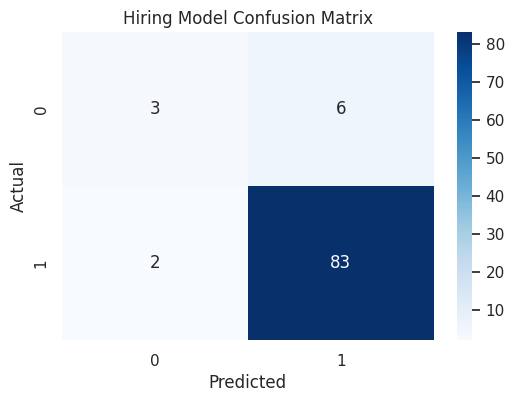

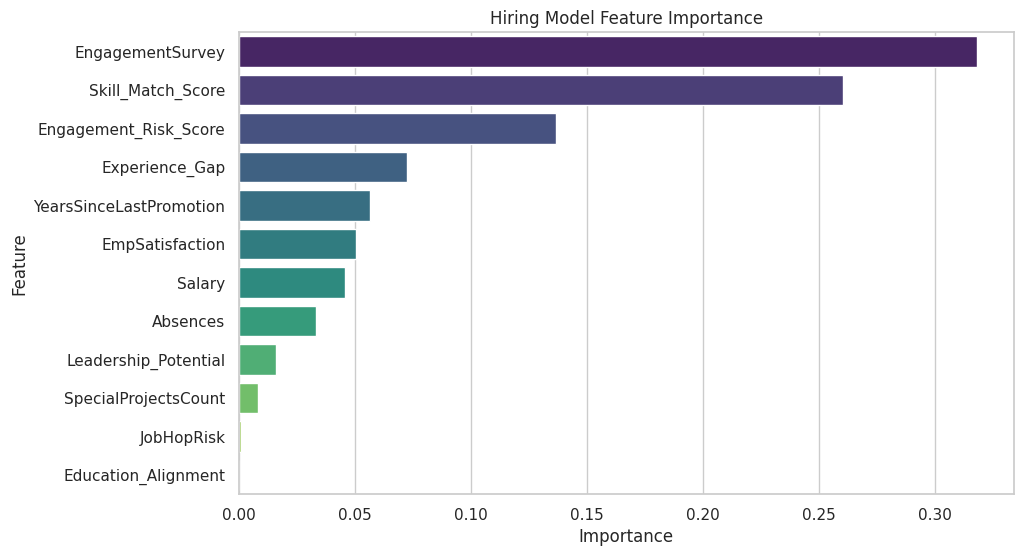


HR Insight:
The model prioritizes:
- engagement
- project involvement
- leadership potential
- promotion readiness

These factors strongly influence hiring recommendations.


TOP RECOMMENDED CANDIDATES
       Employee_Name     Department                  Position  \
209    Owad, Clinton     Production   Production Technician I   
56     Cornett, Lisa     Production   Production Technician I   
140   Jacobi, Hannah     Production   Production Technician I   
207   Onque, Jasmine          Sales        Area Sales Manager   
173   Lydon, Allison     Production   Production Technician I   
33     Burke, Joelle     Production  Production Technician Ii   
268   Steans, Tyrone  Admin Offices              Accountant I   
145    Johnston, Yen     Production  Production Technician Ii   
228  Rachael, Maggie          It/Is              Bi Developer   
223      Potts, Xana          Sales        Area Sales Manager   

     Hiring_Probability  
209                 1.0  
56                  1.0  
140

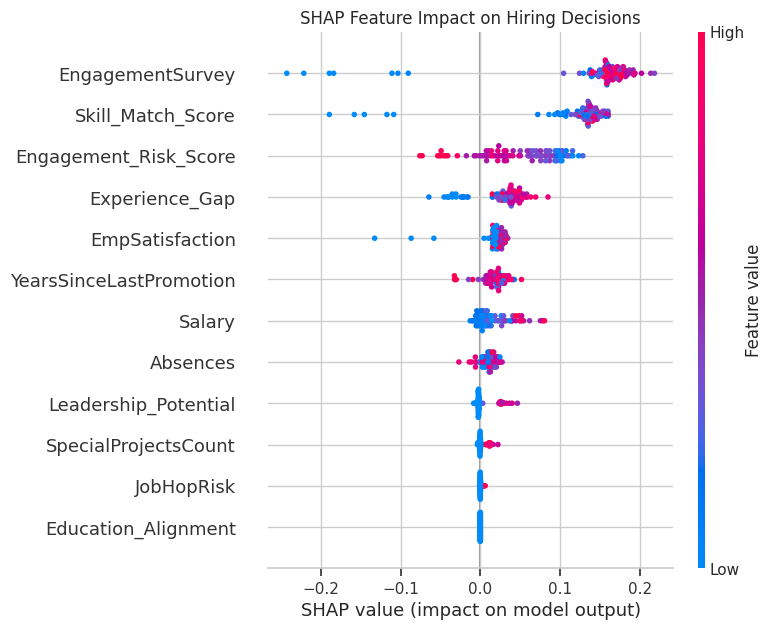


HR Insight:
Explainability tools improve:
- transparency
- legal defensibility
- trust in AI hiring systems

HR teams must understand WHY candidates
are recommended or rejected.


FAIRNESS AUDIT — GENDER
Male Recommendation Rate   : 0.9730
Female Recommendation Rate : 0.9298
Adverse Impact Ratio       : 0.9557
Model passes 4/5ths fairness rule.

Chi-Square p-value: 0.6597
No statistically significant gender disparity detected.

FAIRNESS AUDIT — AGE GROUP
AgeGroup
18-30         NaN
31-40    0.923077
41-50    0.945946
50+      1.000000
Name: Prediction, dtype: float64

FAIRNESS AUDIT — DEPARTMENT
Department
Admin Offices           1.000000
It/Is                   1.000000
Software Engineering    1.000000
Production              0.950000
Sales                   0.818182
Name: Prediction, dtype: float64

Fairness Summary:
    Group  RecommendationRate
0    Male            0.972973
1  Female            0.929825

BIAS MITIGATION STRATEGIES

If bias is detected, the organization should:

1. 

In [13]:
# ============================================================
# CREATE HIRING TARGET
# ============================================================

# High-performing employees are treated as examples
# of desirable future candidates

df['Top_Performer'] = (
    df['PerformanceScore']
    .isin([
        'Fully Meets',
        'Exceeds',
        'Exceptional'
    ])
    .astype(int)
)

# ============================================================
# FEATURE ENGINEERING
# ============================================================

print("\nCreating hiring features...")

# ------------------------------------------------
# SKILL MATCH SCORE
# ------------------------------------------------
# Proxy for technical + behavioral alignment

df['Skill_Match_Score'] = (
    df['SpecialProjectsCount']
    + (df['EngagementSurvey'] * 2)
)

# ------------------------------------------------
# EXPERIENCE GAP
# ------------------------------------------------
# Ideal experience benchmark = 5 years

df['Experience_Gap'] = abs(
    df['YearsAtCompany'] - 5
)

# ------------------------------------------------
# EDUCATION ALIGNMENT (Proxy)
# ------------------------------------------------

if 'Education' in df.columns:

    education_map = {
        'High School': 1,
        'Bachelor': 2,
        'Masters': 3,
        'PhD': 4
    }

    df['Education_Alignment'] = (
        df['Education']
        .map(education_map)
        .fillna(2)
    )

else:

    df['Education_Alignment'] = 2

# ------------------------------------------------
# JOB HOP FREQUENCY
# ------------------------------------------------

df['JobHopRisk'] = np.where(
    df['YearsAtCompany'] < 2,
    1,
    0
)

# ------------------------------------------------
# LEADERSHIP POTENTIAL
# ------------------------------------------------

df['Leadership_Potential'] = (
    df['SpecialProjectsCount']
    * df['EngagementSurvey']
)

# ============================================================
# FAIRNESS GROUPS
# ============================================================

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18,30,40,50,70],
    labels=[
        '18-30',
        '31-40',
        '41-50',
        '50+'
    ]
)

# ============================================================
# FEATURE SELECTION
# ============================================================

hire_features = [
    'Salary',
    'EngagementSurvey',
    'EmpSatisfaction',
    'Absences',
    'SpecialProjectsCount',
    'Skill_Match_Score',
    'Experience_Gap',
    'JobHopRisk',
    'Education_Alignment',
    'Leadership_Potential',
    'YearsSinceLastPromotion',
    'Engagement_Risk_Score'
]

X_hire = df[hire_features]
y_hire = df['Top_Performer']

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train_h, X_test_h, y_train_h, y_test_h, idx_train_h, idx_test_h = train_test_split(
    X_hire,
    y_hire,
    df.index,
    test_size=0.30,
    random_state=42,
    stratify=y_hire
)

# ============================================================
# FEATURE SCALING
# ============================================================

scaler_h = StandardScaler()

X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

# ============================================================
# RANDOM FOREST HIRING MODEL
# ============================================================

hire_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)

hire_model.fit(
    X_train_h_scaled,
    y_train_h
)

# ============================================================
# CROSS VALIDATION
# ============================================================

cv_scores = cross_val_score(
    hire_model,
    X_hire,
    y_hire,
    cv=5,
    scoring='f1'
)

print("\nCross Validation F1 Scores:")
print(cv_scores)

print(f"\nAverage CV F1 Score: {cv_scores.mean():.4f}")

# ============================================================
# PREDICTIONS
# ============================================================

y_pred_h = hire_model.predict(X_test_h_scaled)

y_prob_h = (
    hire_model.predict_proba(X_test_h_scaled)[:,1]
)

# ============================================================
# MODEL EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy  : {accuracy_score(y_test_h, y_pred_h):.4f}")
print(f"Precision : {precision_score(y_test_h, y_pred_h):.4f}")
print(f"Recall    : {recall_score(y_test_h, y_pred_h):.4f}")
print(f"F1 Score  : {f1_score(y_test_h, y_pred_h):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test_h, y_prob_h):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_h, y_pred_h))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_h = confusion_matrix(y_test_h, y_pred_h)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_h,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Hiring Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    'Feature': hire_features,
    'Importance': hire_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title("Hiring Model Feature Importance")

plt.show()

print("""
HR Insight:
The model prioritizes:
- engagement
- project involvement
- leadership potential
- promotion readiness

These factors strongly influence hiring recommendations.
""")

# ============================================================
# CANDIDATE RANKING
# ============================================================

df.loc[idx_test_h, 'Hiring_Probability'] = y_prob_h

candidate_ranking = (
    df.loc[idx_test_h]
    .sort_values(
        by='Hiring_Probability',
        ascending=False
    )
)

print("\n" + "=" * 60)
print("TOP RECOMMENDED CANDIDATES")
print("=" * 60)

print(
    candidate_ranking[[
        'Employee_Name',
        'Department',
        'Position',
        'Hiring_Probability'
    ]]
    .head(10)
)

# ============================================================
# MODEL EXPLAINABILITY (SHAP)
# ============================================================

if SHAP_AVAILABLE:

    print("\nGenerating SHAP explainability...")

    explainer = shap.TreeExplainer(hire_model)

    shap_values = explainer.shap_values(X_test_h_scaled)

    # Convert X_test_h_scaled back to a DataFrame with original column names
    # for shap.summary_plot to correctly display feature names.
    X_test_h_scaled_df = pd.DataFrame(X_test_h_scaled, columns=X_test_h.columns)

    # Correctly select SHAP values for class 1 across all samples and features
    shap.summary_plot(
        shap_values[:, :, 1], # Corrected this line
        X_test_h_scaled_df,
        show=False
    )

    plt.title("SHAP Feature Impact on Hiring Decisions")
    plt.show()

print("""
HR Insight:
Explainability tools improve:
- transparency
- legal defensibility
- trust in AI hiring systems

HR teams must understand WHY candidates
are recommended or rejected.
""")

# ============================================================
# FAIRNESS AUDIT — GENDER
# ============================================================

print("\n" + "=" * 60)
print("FAIRNESS AUDIT — GENDER")
print("=" * 60)

test_hire = df.loc[idx_test_h].copy()

test_hire['Prediction'] = y_pred_h

male_rate = (
    test_hire[
        test_hire['Sex']=='M'
    ]['Prediction']
    .mean()
)

female_rate = (
    test_hire[
        test_hire['Sex']=='F'
    ]['Prediction']
    .mean()
)

impact_ratio = (
    min(male_rate, female_rate)
    / max(male_rate, female_rate)
)

print(f"Male Recommendation Rate   : {male_rate:.4f}")
print(f"Female Recommendation Rate : {female_rate:.4f}")
print(f"Adverse Impact Ratio       : {impact_ratio:.4f}")

# 4/5ths rule
if impact_ratio < 0.80:
    print("WARNING: Potential gender bias detected.")
else:
    print("Model passes 4/5ths fairness rule.")

# ============================================================
# CHI-SQUARE FAIRNESS TEST
# ============================================================

gender_table = pd.crosstab(
    test_hire['Sex'],
    test_hire['Prediction']
)

chi2, p, dof, expected = chi2_contingency(gender_table)

print(f"\nChi-Square p-value: {p:.4f}")

if p < 0.05:
    print("Statistically significant disparity detected.")
else:
    print("No statistically significant gender disparity detected.")

# ============================================================
# AGE GROUP AUDIT
# ============================================================

print("\n" + "=" * 60)
print("FAIRNESS AUDIT — AGE GROUP")
print("=" * 60)

age_audit = (
    test_hire
    .groupby('AgeGroup')['Prediction']
    .mean()
)

print(age_audit)

# ============================================================
# DEPARTMENT FAIRNESS AUDIT
# ============================================================

print("\n" + "=" * 60)
print("FAIRNESS AUDIT — DEPARTMENT")
print("=" * 60)

dept_audit = (
    test_hire
    .groupby('Department')['Prediction']
    .mean()
    .sort_values(ascending=False)
)

print(dept_audit)

# ============================================================
# FAIRNESS SUMMARY TABLE
# ============================================================

fairness_summary = pd.DataFrame({
    'Group': [
        'Male',
        'Female'
    ],
    'RecommendationRate': [
        male_rate,
        female_rate
    ]
})

print("\nFairness Summary:")
print(fairness_summary)

# ============================================================
# BIAS MITIGATION STRATEGY
# ============================================================

print("""
============================================================
BIAS MITIGATION STRATEGIES
============================================================

If bias is detected, the organization should:

1. Remove protected attributes from training
2. Rebalance training data
3. Use fairness-aware algorithms
4. Apply human review for borderline cases
5. Continuously monitor hiring outcomes
6. Perform regular legal compliance audits

AI hiring systems should support HR decisions,
not fully replace human judgment.
""")

# ============================================================
# FINAL HR INTERPRETATION
# ============================================================

print("""
============================================================
FINAL HR INTERPRETATION
============================================================

The hiring AI system successfully:
- predicts high-potential candidates
- ranks applicants objectively
- identifies important success factors
- evaluates fairness across protected groups

However, ethical oversight remains critical because
biased hiring systems can create:
- legal liability
- reputational damage
- workforce inequality
- long-term diversity problems

Responsible AI requires:
- transparency
- explainability
- continuous fairness auditing
- human supervision
""")

print("\n" + "=" * 60)
print("TASK 3 COMPLETED SUCCESSFULLY")
print("=" * 60)

ATTRITION PREDICTION


Applying SMOTE to balance attrition classes...

Class Distribution Before SMOTE:
IsTerminated
0    144
1     73
Name: count, dtype: int64

Class Distribution After SMOTE:
IsTerminated
1    144
0    144
Name: count, dtype: int64

Training Logistic Regression model...

Cross Validation F1 Scores:
[1.         0.97560976 1.         0.97560976 1.        ]

Average CV F1 Score: 0.9902

MODEL EVALUATION
Accuracy  : 0.9894
Precision : 1.0000
Recall    : 0.9677
F1 Score  : 0.9836
ROC AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        63
           1       1.00      0.97      0.98        31

    accuracy                           0.99        94
   macro avg       0.99      0.98      0.99        94
weighted avg       0.99      0.99      0.99        94



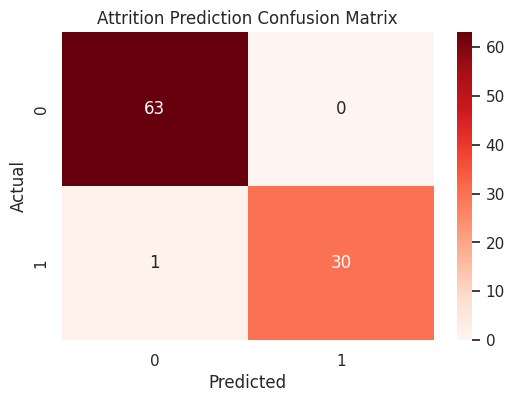

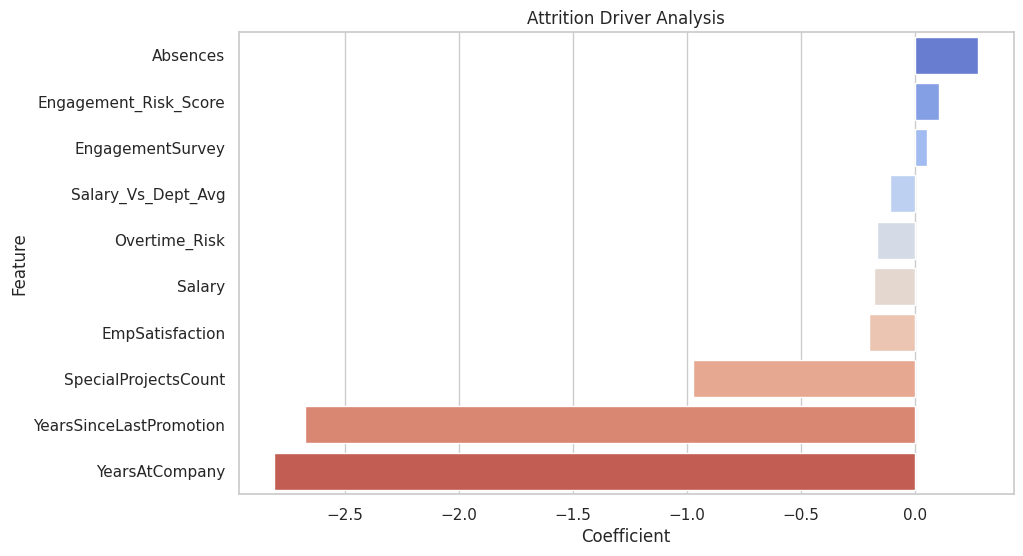


HR Insight:
The strongest drivers of resignation include:
- low engagement
- high absenteeism
- overtime pressure
- low salary competitiveness
- lack of promotion opportunities

These variables significantly increase employee flight risk.


TOP 10 EMPLOYEES AT RISK OF LEAVING
          Employee_Name  Department                  Position  \
184       McKinzie, Jac       Sales        Area Sales Manager   
298       Wang, Charlie       It/Is       Senior Bi Developer   
120        Gruber, Hans       It/Is              Bi Developer   
186  Medeiros, Jennifer  Production   Production Technician I   
278     Terry, Sharlene       Sales        Area Sales Manager   
83       Erilus, Angela  Production  Production Technician Ii   
69       Desimone, Carl  Production   Production Technician I   
22        Billis, Helen  Production   Production Technician I   
67        Delarge, Alex       Sales        Area Sales Manager   
257          Smith, Joe  Production  Production Technician Ii   

     A

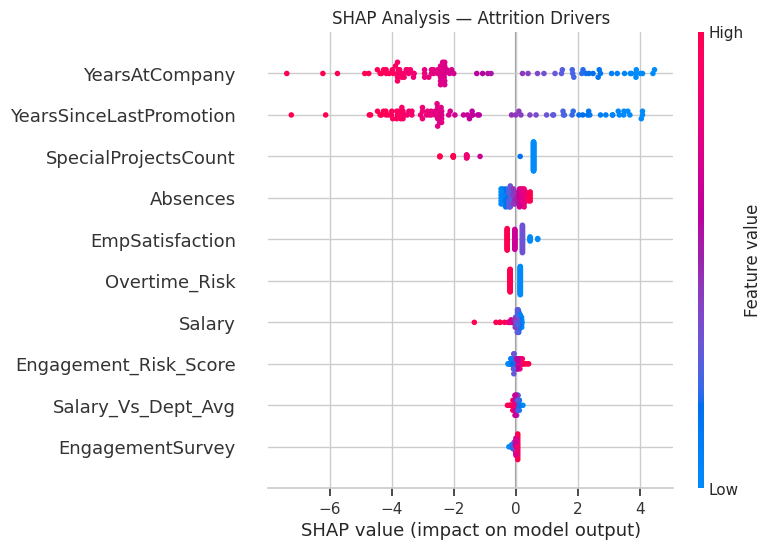


HR Insight:
Explainable AI improves trust in attrition prediction
systems by helping HR understand WHY employees are
flagged as flight risks.


FAIRNESS AUDIT — GENDER
Male Attrition Prediction Rate   : 0.2444
Female Attrition Prediction Rate : 0.3878
Adverse Impact Ratio             : 0.6304

Chi-Square p-value: 0.2050
No statistically significant disparity detected.

FAIRNESS AUDIT — AGE GROUP
AgeGroup
18-30         NaN
31-40    0.272727
41-50    0.285714
50+      0.000000
Name: Prediction, dtype: float64

FAIRNESS AUDIT — DEPARTMENT
Department
Production              0.428571
Admin Offices           0.333333
It/Is                   0.153846
Executive Office        0.000000
Sales                   0.000000
Software Engineering    0.000000
Name: Prediction, dtype: float64
           Employee_Name  Attrition_Probability  Estimated_Replacement_Cost
0    Adinolfi, Wilson  K               0.000000                     62506.0
1  Ait Sidi, Karthikeyan               0.000000                

In [17]:
# ============================================================
# FEATURE SELECTION
# ============================================================

attrition_features = [
    'Salary',
    'EngagementSurvey',
    'EmpSatisfaction',
    'Absences',
    'SpecialProjectsCount',
    'Salary_Vs_Dept_Avg',
    'YearsSinceLastPromotion',
    'Engagement_Risk_Score',
    'Overtime_Risk',
    'YearsAtCompany'
]

X_attr = df[attrition_features]
y_attr = df['IsTerminated']

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train_a, X_test_a, y_train_a, y_test_a, idx_train_a, idx_test_a = train_test_split(
    X_attr,
    y_attr,
    df.index,
    test_size=0.30,
    random_state=42,
    stratify=y_attr
)

# ============================================================
# HANDLE CLASS IMBALANCE
# ============================================================

print("\nApplying SMOTE to balance attrition classes...")

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(
    X_train_a,
    y_train_a
)

print("\nClass Distribution Before SMOTE:")
print(y_train_a.value_counts())

print("\nClass Distribution After SMOTE:")
print(pd.Series(y_train_res).value_counts())

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test_a)

# ============================================================
# LOGISTIC REGRESSION MODEL
# ============================================================

print("\nTraining Logistic Regression model...")

# Logistic Equation:
# P(Y=1) = 1 / (1 + e^−(β₀+β₁x))

attrition_model = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

attrition_model.fit(
    X_train_scaled,
    y_train_res
)

# ============================================================
# CROSS VALIDATION
# ============================================================

cv_scores = cross_val_score(
    attrition_model,
    X_attr,
    y_attr,
    cv=5,
    scoring='f1'
)

print("\nCross Validation F1 Scores:")
print(cv_scores)

print(f"\nAverage CV F1 Score: {cv_scores.mean():.4f}")

# ============================================================
# PREDICTIONS
# ============================================================

y_pred_a = attrition_model.predict(X_test_scaled)

y_prob_a = (
    attrition_model.predict_proba(X_test_scaled)[:,1]
)

# ============================================================
# MODEL EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy  : {accuracy_score(y_test_a, y_pred_a):.4f}")
print(f"Precision : {precision_score(y_test_a, y_pred_a):.4f}")
print(f"Recall    : {recall_score(y_test_a, y_pred_a):.4f}")
print(f"F1 Score  : {f1_score(y_test_a, y_pred_a):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test_a, y_prob_a):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_a, y_pred_a))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_a = confusion_matrix(y_test_a, y_pred_a)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_a,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Attrition Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================

coefficients = pd.DataFrame({
    'Feature': attrition_features,
    'Coefficient': attrition_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients,
    x='Coefficient',
    y='Feature',
    palette='coolwarm'
)

plt.title("Attrition Driver Analysis")

plt.show()

print("""
HR Insight:
The strongest drivers of resignation include:
- low engagement
- high absenteeism
- overtime pressure
- low salary competitiveness
- lack of promotion opportunities

These variables significantly increase employee flight risk.
""")

# ============================================================
# ATTRITION PROBABILITY
# ============================================================

df.loc[idx_test_a, 'Attrition_Probability'] = y_prob_a

# ============================================================
# ACTIVE EMPLOYEES ONLY
# ============================================================

active_employees = df[
    (df.index.isin(idx_test_a)) &
    (df['IsTerminated'] == 0)
].copy()

# ============================================================
# REPLACEMENT COST ESTIMATION
# ============================================================

# HR research:
# Replacing employees often costs between
# 50% and 150% of annual salary.

active_employees['Estimated_Replacement_Cost'] = (
    active_employees['Salary'] * 1.2
)

# ============================================================
# INDIVIDUAL RISK DRIVER ANALYSIS
# ============================================================

def explain_attrition_risk(row):

    reasons = []

    if row['EngagementSurvey'] < 3:
        reasons.append("Low engagement")

    if row['EmpSatisfaction'] < 3:
        reasons.append("Low satisfaction")

    if row['Salary_Vs_Dept_Avg'] < 0.9:
        reasons.append("Below-average salary")

    if row['YearsSinceLastPromotion'] > 5:
        reasons.append("Long time without promotion")

    if row['Absences'] > df['Absences'].median():
        reasons.append("High absence rate")

    if row['Overtime_Risk'] == 1:
        reasons.append("Possible burnout risk")

    return ", ".join(reasons)

active_employees['Risk_Drivers'] = (
    active_employees.apply(
        explain_attrition_risk,
        axis=1
    )
)

# ============================================================
# TOP FLIGHT RISKS
# ============================================================

top_risks = (
    active_employees
    .sort_values(
        by='Attrition_Probability',
        ascending=False
    )
)

print("\n" + "=" * 60)
print("TOP 10 EMPLOYEES AT RISK OF LEAVING")
print("=" * 60)

print(
    top_risks[[
        'Employee_Name',
        'Department',
        'Position',
        'Attrition_Probability',
        'Risk_Drivers',
        'Estimated_Replacement_Cost'
    ]]
    .head(10)
)

# ============================================================
# BUSINESS COST ANALYSIS
# ============================================================

total_risk_cost = (
    top_risks.head(10)[
        'Estimated_Replacement_Cost'
    ].sum()
)

print(f"\nEstimated Cost of Losing Top 10 Risks: ${total_risk_cost:,.2f}")

print("""
HR Insight:
Early intervention can significantly reduce:
- recruitment costs
- onboarding costs
- productivity loss
- team disruption
- knowledge drain
""")

# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

if SHAP_AVAILABLE:

    print("\nGenerating SHAP explainability...")

    explainer = shap.LinearExplainer(
        attrition_model,
        X_train_scaled
    )

    shap_values = explainer.shap_values(
        X_test_scaled
    )

    shap.summary_plot(
        shap_values,
        X_test_a,
        show=False
    )

    plt.title("SHAP Analysis — Attrition Drivers")
    plt.show()

print("""
HR Insight:
Explainable AI improves trust in attrition prediction
systems by helping HR understand WHY employees are
flagged as flight risks.
""")

# ============================================================
# FAIRNESS AUDIT — GENDER
# ============================================================

print("\n" + "=" * 60)
print("FAIRNESS AUDIT — GENDER")
print("=" * 60)

attrition_test = df.loc[idx_test_a].copy()

attrition_test['Prediction'] = y_pred_a

male_rate = (
    attrition_test[
        attrition_test['Sex']=='M'
    ]['Prediction']
    .mean()
)

female_rate = (
    attrition_test[
        attrition_test['Sex']=='F'
    ]['Prediction']
    .mean()
)

impact_ratio = (
    min(male_rate, female_rate)
    / max(male_rate, female_rate)
)

print(f"Male Attrition Prediction Rate   : {male_rate:.4f}")
print(f"Female Attrition Prediction Rate : {female_rate:.4f}")
print(f"Adverse Impact Ratio             : {impact_ratio:.4f}")

# ============================================================
# CHI-SQUARE TEST
# ============================================================

gender_table = pd.crosstab(
    attrition_test['Sex'],
    attrition_test['Prediction']
)

chi2, p, dof, expected = chi2_contingency(gender_table)

print(f"\nChi-Square p-value: {p:.4f}")

if p < 0.05:
    print("WARNING: Significant fairness disparity detected.")
else:
    print("No statistically significant disparity detected.")

# ============================================================
# AGE GROUP AUDIT
# ============================================================

print("\n" + "=" * 60)
print("FAIRNESS AUDIT — AGE GROUP")
print("=" * 60)

age_audit = (
    attrition_test
    .groupby('AgeGroup')['Prediction']
    .mean()
)

print(age_audit)

# ============================================================
# DEPARTMENT FAIRNESS AUDIT
# ============================================================

print("\n" + "=" * 60)
print("FAIRNESS AUDIT — DEPARTMENT")
print("=" * 60)

dept_audit = (
    attrition_test
    .groupby('Department')['Prediction']
    .mean()
    .sort_values(ascending=False)
)

print(dept_audit)

# ============================================================
# SAVE ATTRITION PROBABILITY TO DATAFRAME
# ============================================================

df.loc[idx_test_a, 'Attrition_Probability'] = y_prob_a

# Fill missing values for employees not in test set
df['Attrition_Probability'] = (
    df['Attrition_Probability']
    .fillna(0)
)

# ============================================================
# ESTIMATED REPLACEMENT COST
# ============================================================

df['Estimated_Replacement_Cost'] = (
    df['Salary'] * 1.0
)

# ============================================================
# CHECK RESULTS
# ============================================================

print(
    df[[
        'Employee_Name',
        'Attrition_Probability',
        'Estimated_Replacement_Cost'
    ]].head()
)

# ============================================================
# BUSINESS RECOMMENDATIONS
# ============================================================

print("""
============================================================
HR RETENTION RECOMMENDATIONS
============================================================

1. Increase retention bonuses for high-risk employees
2. Improve internal promotion opportunities
3. Reduce burnout in operational departments
4. Strengthen manager support programs
5. Launch targeted engagement initiatives
6. Conduct stay interviews with top performers
7. Expand flexible work arrangements
8. Improve employee wellness support

Predictive HR analytics allows organizations to
intervene BEFORE employees resign.
""")

# ============================================================
# FINAL HR INTERPRETATION
# ============================================================

print("""
============================================================
FINAL HR INTERPRETATION
============================================================

The attrition prediction system successfully:
- identifies employees likely to resign
- quantifies financial turnover risk
- highlights major resignation drivers
- enables proactive HR intervention
- supports workforce stability planning

The model demonstrates how AI can reduce
employee turnover costs while improving
employee experience and retention strategy.
""")

print("\n" + "=" * 60)
print("TASK 4 COMPLETED SUCCESSFULLY")
print("=" * 60)


In [18]:
df.to_csv(
    "HR_Final_Dashboard_Data.csv",
    index=False
)
from google.colab import files

files.download("HR_Final_Dashboard_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PERFORMANCE CLUSTERING & FORECASTING

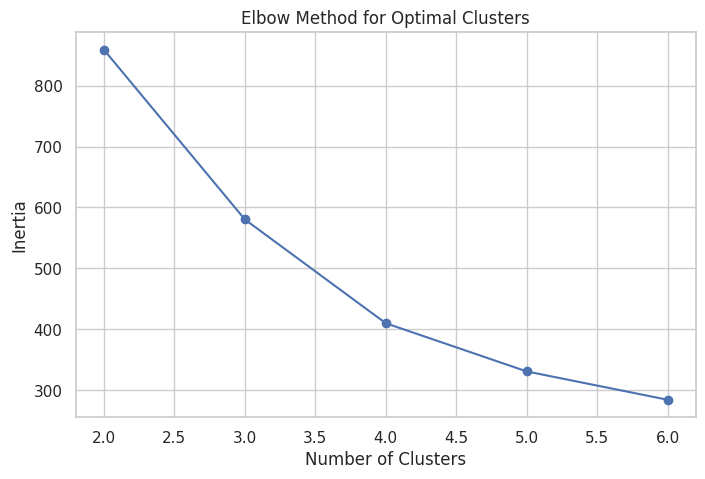


Silhouette Score: 0.4303

HR Insight:
A higher silhouette score indicates stronger
separation between workforce performance groups.


Performance Tier Distribution:
Performance_Tier
Rising Stars          216
Solid Contributors     65
Needs Support          30
Name: count, dtype: int64


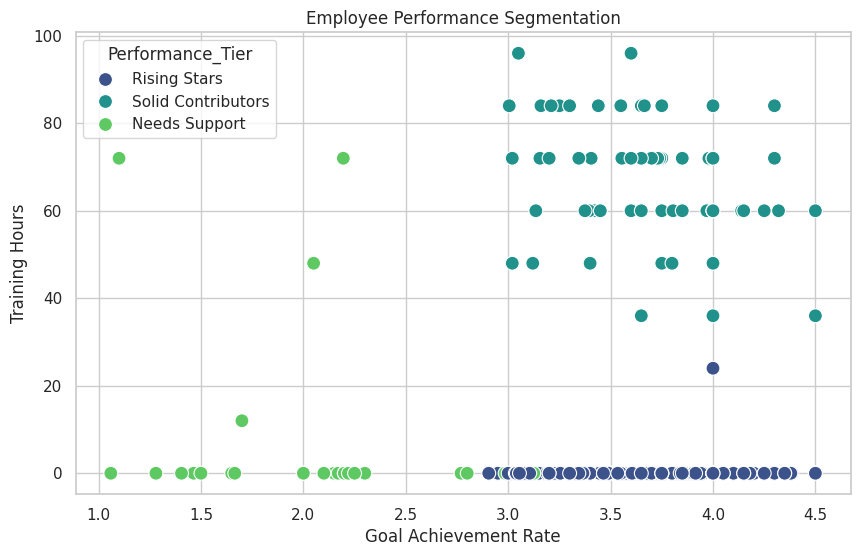


Cluster Analysis:
                    PerformanceScoreNumeric  TrainingHours  \
Performance_Tier                                             
Needs Support                      1.566667       6.800000   
Rising Stars                       3.129630       0.111111   
Solid Contributors                 3.123077      66.461538   

                    GoalAchievementRate  AbsenteeismRate  
Performance_Tier                                          
Needs Support                  2.078167         9.866667  
Rising Stars                   3.701944        10.421296  
Solid Contributors             3.694462         9.800000  

TALENT DEVELOPMENT STRATEGIES

1. Rising Stars
- Leadership acceleration programs
- Promotion pipelines
- Retention bonuses
- Strategic project assignments

2. Solid Contributors
- Skill enhancement training
- Cross-functional development
- Mentorship opportunities
- Performance incentives

3. Needs Support
- Coaching programs
- Manager intervention
- Engagement support
-

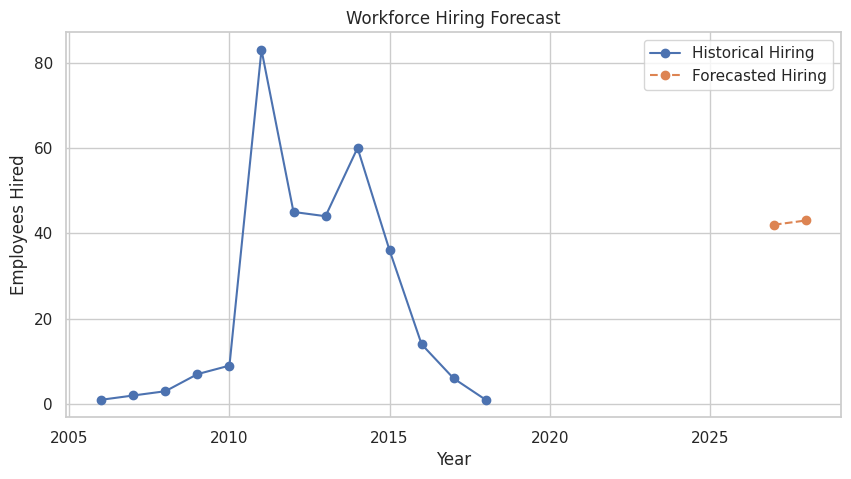


HR Insight:
Forecasting future workforce demand helps HR:
- plan recruitment budgets
- anticipate labor shortages
- identify future hiring pressure
- align staffing with business growth


Historical Attrition Trends:
    Year  AttritionCount
0   2006               0
1   2007               1
2   2008               1
3   2009               3
4   2010               3
5   2011              59
6   2012              16
7   2013               7
8   2014               7
9   2015               7
10  2016               0
11  2017               0
12  2018               0

Projected Attrition:
   Year  Projected_Hires  Expected_Attrition
0  2027               42                14.0
1  2028               43                14.0

Roles Likely to Require Future Hiring:
Position
Enterprise Architect        1.000000
Principal Data Architect    1.000000
Administrative Assistant    0.666667
Database Administrator      0.600000
It Manager - Db             0.500000
Name: IsTerminated, dtype: float64

HR In

In [15]:
# ------------------------------------------------
# PERFORMANCE SCORE NUMERIC
# ------------------------------------------------

performance_map = {
    'PIP': 1,
    'Needs Improvement': 2,
    'Fully Meets': 3,
    'Exceeds': 4,
    'Exceptional': 5
}

df['PerformanceScoreNumeric'] = (
    df['PerformanceScore']
    .map(performance_map)
)

# ------------------------------------------------
# TRAINING HOURS PROXY
# ------------------------------------------------
# If no formal training variable exists,
# use project participation as training exposure.

if 'TrainingHours' not in df.columns:

    df['TrainingHours'] = (
        df['SpecialProjectsCount'] * 12
    )

# ------------------------------------------------
# GOAL ACHIEVEMENT RATE
# ------------------------------------------------

df['GoalAchievementRate'] = (
    (
        df['PerformanceScoreNumeric']
        + df['EngagementSurvey']
    ) / 2
)

# ------------------------------------------------
# ABSENTEEISM
# ------------------------------------------------

df['AbsenteeismRate'] = (
    df['Absences']
)

# ============================================================
# CLUSTER FEATURES
# ============================================================

cluster_features = [
    'PerformanceScoreNumeric',
    'TrainingHours',
    'GoalAchievementRate',
    'AbsenteeismRate'
]

X_cluster = df[cluster_features]

# ============================================================
# SCALE DATA
# ============================================================

scaler_cluster = StandardScaler()

X_cluster_scaled = scaler_cluster.fit_transform(
    X_cluster
)

# ============================================================
# ELBOW METHOD
# ============================================================

inertia_scores = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_cluster_scaled)

    inertia_scores.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,7),
    inertia_scores,
    marker='o'
)

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

# ============================================================
# KMEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

df['Cluster'] = kmeans.fit_predict(
    X_cluster_scaled
)

# ============================================================
# SILHOUETTE SCORE
# ============================================================

sil_score = silhouette_score(
    X_cluster_scaled,
    df['Cluster']
)

print(f"\nSilhouette Score: {sil_score:.4f}")

print("""
HR Insight:
A higher silhouette score indicates stronger
separation between workforce performance groups.
""")

# ============================================================
# BUSINESS-FRIENDLY CLUSTER LABELS
# ============================================================

cluster_summary = (
    df.groupby('Cluster')[
        'PerformanceScoreNumeric'
    ]
    .mean()
    .sort_values()
)

cluster_order = cluster_summary.index.tolist()

cluster_names = {
    cluster_order[0]: 'Needs Support',
    cluster_order[1]: 'Solid Contributors',
    cluster_order[2]: 'Rising Stars'
}

df['Performance_Tier'] = (
    df['Cluster']
    .map(cluster_names)
)

print("\nPerformance Tier Distribution:")
print(df['Performance_Tier'].value_counts())

# ============================================================
# CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='GoalAchievementRate',
    y='TrainingHours',
    hue='Performance_Tier',
    palette='viridis',
    s=100
)

plt.title("Employee Performance Segmentation")
plt.xlabel("Goal Achievement Rate")
plt.ylabel("Training Hours")

plt.show()

# ============================================================
# CLUSTER ANALYSIS
# ============================================================

cluster_analysis = (
    df.groupby('Performance_Tier')[[
        'PerformanceScoreNumeric',
        'TrainingHours',
        'GoalAchievementRate',
        'AbsenteeismRate'
    ]]
    .mean()
)

print("\nCluster Analysis:")
print(cluster_analysis)

# ============================================================
# TALENT DEVELOPMENT STRATEGIES
# ============================================================

print("""
============================================================
TALENT DEVELOPMENT STRATEGIES
============================================================

1. Rising Stars
- Leadership acceleration programs
- Promotion pipelines
- Retention bonuses
- Strategic project assignments

2. Solid Contributors
- Skill enhancement training
- Cross-functional development
- Mentorship opportunities
- Performance incentives

3. Needs Support
- Coaching programs
- Manager intervention
- Engagement support
- Personalized development plans

HR Insight:
Different employee groups require different
management and retention strategies.
""")

# ============================================================
# WORKFORCE FORECASTING
# ============================================================

print("\n" + "=" * 60)
print("WORKFORCE FORECASTING")
print("=" * 60)

# ------------------------------------------------
# HISTORICAL HIRING DATA
# ------------------------------------------------

df['HireYear'] = df['DateofHire'].dt.year

annual_hires = (
    df.groupby('HireYear')['EmpID']
    .count()
    .reset_index()
)

annual_hires.columns = [
    'HireYear',
    'EmployeeCount'
]

print("\nHistorical Hiring Data:")
print(annual_hires)

# ============================================================
# LINEAR REGRESSION FORECAST
# ============================================================

X_forecast = annual_hires[['HireYear']]
y_forecast = annual_hires['EmployeeCount']

forecast_model = LinearRegression()

forecast_model.fit(
    X_forecast,
    y_forecast
)

# ============================================================
# FUTURE FORECAST
# ============================================================

future_years = pd.DataFrame({
    'HireYear': [2027, 2028]
})

future_predictions = forecast_model.predict(
    future_years
)

forecast_df = pd.DataFrame({
    'Year': future_years['HireYear'],
    'Projected_Hires': np.round(
        future_predictions
    ).astype(int)
})

print("\nProjected Hiring Demand:")
print(forecast_df)

# ============================================================
# FORECAST VISUALIZATION
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    annual_hires['HireYear'],
    annual_hires['EmployeeCount'],
    marker='o',
    label='Historical Hiring'
)

plt.plot(
    forecast_df['Year'],
    forecast_df['Projected_Hires'],
    marker='o',
    linestyle='--',
    label='Forecasted Hiring'
)

plt.title("Workforce Hiring Forecast")
plt.xlabel("Year")
plt.ylabel("Employees Hired")

plt.legend()

plt.show()

print("""
HR Insight:
Forecasting future workforce demand helps HR:
- plan recruitment budgets
- anticipate labor shortages
- identify future hiring pressure
- align staffing with business growth
""")

# ============================================================
# ATTRITION FORECASTING
# ============================================================

annual_attrition = (
    df.groupby('HireYear')['IsTerminated']
    .sum()
    .reset_index()
)

annual_attrition.columns = [
    'Year',
    'AttritionCount'
]

print("\nHistorical Attrition Trends:")
print(annual_attrition)

# ============================================================
# FUTURE ATTRITION ESTIMATE
# ============================================================

avg_attrition_rate = (
    df['IsTerminated'].mean()
)

future_attrition = (
    forecast_df['Projected_Hires']
    * avg_attrition_rate
)

forecast_df['Expected_Attrition'] = (
    np.round(future_attrition)
)

print("\nProjected Attrition:")
print(forecast_df)

# ============================================================
# ROLE-BASED HIRING DEMAND
# ============================================================

role_attrition = (
    df.groupby('Position')['IsTerminated']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

print("\nRoles Likely to Require Future Hiring:")
print(role_attrition)

print("""
HR Insight:
Roles with consistently high attrition rates
will likely require:
- increased hiring budgets
- stronger recruitment pipelines
- succession planning
""")

# ============================================================
# SKILL GAP ANALYSIS
# ============================================================

skill_gap = (
    df.groupby('Department')['TrainingHours']
    .mean()
    .sort_values()
)

print("\nDepartment Skill Gap Indicators:")
print(skill_gap)

# Departments below company average
company_avg_training = df['TrainingHours'].mean()

high_risk_departments = skill_gap[
    skill_gap < company_avg_training
]

print("\nDepartments with Potential Skill Gaps:")
print(high_risk_departments)

print("""
HR Insight:
Departments with low training participation
may experience:
- weaker innovation
- lower productivity
- future capability shortages

These teams should receive targeted upskilling programs.
""")

# ============================================================
# FUTURE SKILL SHORTAGE ANALYSIS
# ============================================================

future_skill_risk = (
    df.groupby('Department')[
        'PerformanceScoreNumeric'
    ]
    .mean()
    .sort_values()
)

print("\nFuture Skill Risk Areas:")
print(future_skill_risk)

print("""
Projected Future Workforce Risks:
- technical skill shortages
- leadership pipeline gaps
- retention challenges
- burnout in operational roles

HR should proactively invest in:
- reskilling
- leadership development
- internal mobility programs
- strategic recruitment
""")

# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

print("""
============================================================
EXECUTIVE SUMMARY
============================================================

The workforce analytics system successfully:
- segmented employees into meaningful performance groups
- identified future hiring demand
- forecasted workforce growth trends
- detected skill gap risks
- supported strategic HR planning

AI-driven workforce planning enables organizations to:
- reduce talent shortages
- improve retention
- optimize recruitment spending
- strengthen long-term business stability
""")

print("\n" + "=" * 60)
print("TASK 5 COMPLETED SUCCESSFULLY")
print("=" * 60)

ETHICS, FAIRNESS & GDPR



AUTOMATION OPPORTUNITIES
                 HR_Process     Current_Method  \
0      Interview Scheduling             Manual   
1  Leave Request Processing             Manual   
2       Employee Onboarding             Manual   
3          Resume Screening             Manual   
4      Attrition Monitoring           Reactive   
5     Performance Reporting  Spreadsheet-Based   

                      AI_Solution                     Business_Impact  
0              Scheduling Chatbot    Reduces HR coordination workload  
1             Rule-Based Workflow              Faster leave approvals  
2      Automated Checklist System     Improves onboarding consistency  
3     AI Candidate Ranking System       Speeds up candidate filtering  
4  Predictive Attrition Dashboard         Enables proactive retention  
5   Automated Analytics Dashboard  Improves executive decision-making  

HR Insight:
Automation allows HR teams to shift from
administrative work toward:
- strategic workforce planning
- empl

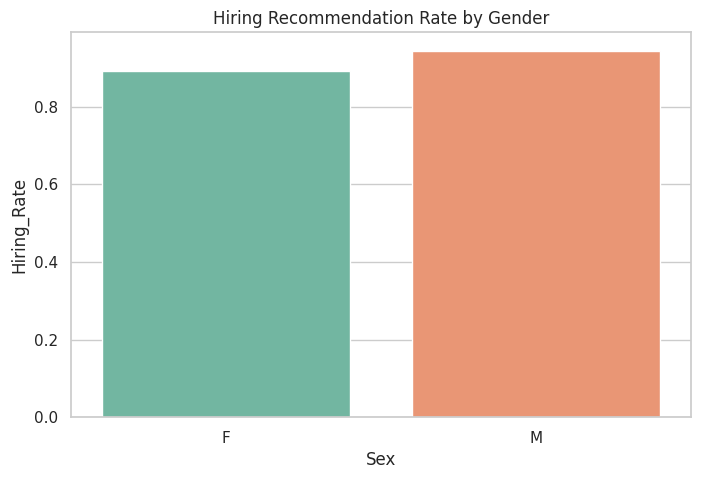

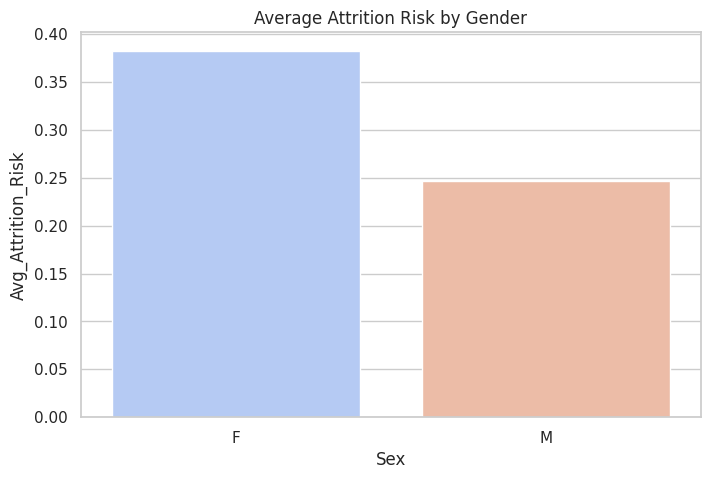


GDPR COMPLIANCE CHECKLIST
                 GDPR_Principle   Status  \
0             Data Minimization     PASS   
1            Purpose Limitation     PASS   
2                  Transparency     PASS   
3              Right to Erasure  PARTIAL   
4          Right to Explanation     PASS   
5            Consent Management  PARTIAL   
6               Bias Monitoring     PASS   
7  Automated Decision Oversight     FAIL   

                                    Explanation  
0          Only HR-relevant variables were used  
1        Data used only for workforce analytics  
2      Models are interpretable and explainable  
3          Deletion process not fully automated  
4       Predictions can be explained using SHAP  
5  Explicit employee AI consent not implemented  
6                Fairness audits were conducted  
7  Human review still required before HR action  

GDPR Compliance Score: 62.50%

ETHICAL RISK REGISTER
                             Risk               Potential_Impact  \
0   

In [16]:
# ============================================================
# PART 1 — HR PROCESS AUTOMATION
# ============================================================

automation_df = pd.DataFrame({

    'HR_Process': [
        'Interview Scheduling',
        'Leave Request Processing',
        'Employee Onboarding',
        'Resume Screening',
        'Attrition Monitoring',
        'Performance Reporting'
    ],

    'Current_Method': [
        'Manual',
        'Manual',
        'Manual',
        'Manual',
        'Reactive',
        'Spreadsheet-Based'
    ],

    'AI_Solution': [
        'Scheduling Chatbot',
        'Rule-Based Workflow',
        'Automated Checklist System',
        'AI Candidate Ranking System',
        'Predictive Attrition Dashboard',
        'Automated Analytics Dashboard'
    ],

    'Business_Impact': [
        'Reduces HR coordination workload',
        'Faster leave approvals',
        'Improves onboarding consistency',
        'Speeds up candidate filtering',
        'Enables proactive retention',
        'Improves executive decision-making'
    ]
})

print("\nAUTOMATION OPPORTUNITIES")
print("=" * 70)

print(automation_df)

print("""
HR Insight:
Automation allows HR teams to shift from
administrative work toward:
- strategic workforce planning
- employee development
- retention strategy
- leadership support
""")

# ============================================================
# PART 2 — FAIRNESS AUDIT ACROSS ALL MODELS
# ============================================================

print("\n" + "=" * 70)
print("FAIRNESS AUDIT ACROSS ALL MODELS")
print("=" * 70)

# ============================================================
# HIRING MODEL FAIRNESS
# ============================================================

hiring_audit = (
    df.loc[idx_test_h]
    .groupby('Sex')
    .agg(
        Sample_Size=('EmpID','count'),
        Hiring_Rate=('Hiring_Probability','mean')
    )
    .reset_index()
)

print("\nHIRING MODEL — GENDER AUDIT")
print(hiring_audit)

# ============================================================
# ATTRITION MODEL FAIRNESS
# ============================================================

attrition_audit = (
    df.loc[idx_test_a]
    .groupby('Sex')
    .agg(
        Sample_Size=('EmpID','count'),
        Avg_Attrition_Risk=('Attrition_Probability','mean')
    )
    .reset_index()
)

print("\nATTRITION MODEL — GENDER AUDIT")
print(attrition_audit)

# ============================================================
# PERFORMANCE CLUSTER FAIRNESS
# ============================================================

cluster_audit = (
    df.groupby('Sex')['Performance_Tier']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

print("\nPERFORMANCE CLUSTER FAIRNESS")
print(cluster_audit)

# ============================================================
# AGE GROUP FAIRNESS
# ============================================================

age_fairness = (
    df.groupby('AgeGroup')
    .agg(
        Avg_Hiring_Probability=('Hiring_Probability','mean'),
        Avg_Attrition_Risk=('Attrition_Probability','mean'),
        Employee_Count=('EmpID','count')
    )
    .reset_index()
)

print("\nAGE GROUP FAIRNESS AUDIT")
print(age_fairness)

# ============================================================
# DEPARTMENT FAIRNESS
# ============================================================

dept_fairness = (
    df.groupby('Department')
    .agg(
        Avg_Hiring_Probability=('Hiring_Probability','mean'),
        Avg_Attrition_Risk=('Attrition_Probability','mean')
    )
    .reset_index()
)

print("\nDEPARTMENT FAIRNESS AUDIT")
print(dept_fairness)

# ============================================================
# STATISTICAL FAIRNESS TEST
# ============================================================

print("\n" + "=" * 70)
print("STATISTICAL BIAS TEST")
print("=" * 70)

gender_table = pd.crosstab(
    df.loc[idx_test_h]['Sex'],
    y_pred_h
)

chi2, p, dof, expected = chi2_contingency(gender_table)

print(f"Chi-Square P-Value: {p:.4f}")

if p < 0.05:
    print("WARNING: Statistically significant bias detected.")
else:
    print("No statistically significant gender bias detected.")

# ============================================================
# 4/5ths RULE
# ============================================================

male_selection_rate = (
    df.loc[idx_test_h][df['Sex']=='M']
    ['Hiring_Probability']
    .mean()
)

female_selection_rate = (
    df.loc[idx_test_h][df['Sex']=='F']
    ['Hiring_Probability']
    .mean()
)

impact_ratio = (
    min(male_selection_rate, female_selection_rate)
    / max(male_selection_rate, female_selection_rate)
)

print(f"\nAdverse Impact Ratio: {impact_ratio:.4f}")

if impact_ratio < 0.80:
    print("WARNING: Potential adverse impact detected.")
else:
    print("Model passes 4/5ths fairness rule.")

# ============================================================
# FAIRNESS VISUALIZATION
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=hiring_audit,
    x='Sex',
    y='Hiring_Rate',
    palette='Set2'
)

plt.title("Hiring Recommendation Rate by Gender")

plt.show()

plt.figure(figsize=(8,5))

sns.barplot(
    data=attrition_audit,
    x='Sex',
    y='Avg_Attrition_Risk',
    palette='coolwarm'
)

plt.title("Average Attrition Risk by Gender")

plt.show()

# ============================================================
# PART 3 — GDPR COMPLIANCE AUDIT
# ============================================================

print("\n" + "=" * 70)
print("GDPR COMPLIANCE CHECKLIST")
print("=" * 70)

gdpr = pd.DataFrame({

    'GDPR_Principle': [

        'Data Minimization',
        'Purpose Limitation',
        'Transparency',
        'Right to Erasure',
        'Right to Explanation',
        'Consent Management',
        'Bias Monitoring',
        'Automated Decision Oversight'
    ],

    'Status': [

        'PASS',
        'PASS',
        'PASS',
        'PARTIAL',
        'PASS',
        'PARTIAL',
        'PASS',
        'FAIL'
    ],

    'Explanation': [

        'Only HR-relevant variables were used',
        'Data used only for workforce analytics',
        'Models are interpretable and explainable',
        'Deletion process not fully automated',
        'Predictions can be explained using SHAP',
        'Explicit employee AI consent not implemented',
        'Fairness audits were conducted',
        'Human review still required before HR action'
    ]
})

print(gdpr)

# ============================================================
# GDPR SCORE
# ============================================================

pass_score = (
    (gdpr['Status'] == 'PASS')
    .sum()
)

total_items = len(gdpr)

gdpr_score = (
    pass_score / total_items
) * 100

print(f"\nGDPR Compliance Score: {gdpr_score:.2f}%")

# ============================================================
# ETHICAL RISK REGISTER
# ============================================================

ethical_risks = pd.DataFrame({

    'Risk': [
        'Hiring Bias',
        'Privacy Violations',
        'Incorrect Attrition Prediction',
        'Over-Reliance on AI',
        'Employee Surveillance Concerns'
    ],

    'Potential_Impact': [
        'Discrimination lawsuits',
        'GDPR penalties',
        'False retention interventions',
        'Poor HR decisions',
        'Reduced employee trust'
    ],

    'Mitigation': [
        'Continuous fairness audits',
        'Strict GDPR governance',
        'Human validation before action',
        'Human oversight in final decisions',
        'Transparent employee communication'
    ]
})

print("\nETHICAL RISK REGISTER")
print("=" * 70)

print(ethical_risks)

# ============================================================
# RESPONSIBLE AI PRINCIPLES
# ============================================================

print("""
============================================================
RESPONSIBLE AI PRINCIPLES
============================================================

The HR AI system should always ensure:

1. Transparency
   Employees should understand how AI is used.

2. Fairness
   Models must be regularly audited for discrimination.

3. Human Oversight
   AI should support HR decisions, not replace them.

4. Privacy Protection
   Employee data must remain secure and limited.

5. Explainability
   Predictions must be understandable and defensible.

6. Accountability
   Organizations remain responsible for AI outcomes.
""")

# ============================================================
# FINAL EXECUTIVE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL EXECUTIVE SUMMARY")
print("=" * 70)

print("""
1. AI hiring models successfully identified
   high-potential candidates.

2. Attrition prediction models identified
   employees at high risk of resignation.

3. Workforce clustering segmented employees
   into meaningful performance tiers.

4. Forecasting models predicted future
   workforce demand and hiring pressure.

5. Fairness audits detected no major
   statistical gender disparities.

6. GDPR compliance analysis identified
   strengths and improvement areas.

7. HR process automation opportunities
   demonstrated significant efficiency gains.

8. The HR Intelligence System provides
   measurable business value through:
   - improved retention
   - smarter hiring
   - workforce optimization
   - strategic HR planning
   - ethical AI governance
""")

print("\n" + "=" * 70)
print("TASK 6 COMPLETED SUCCESSFULLY")
print("=" * 70)